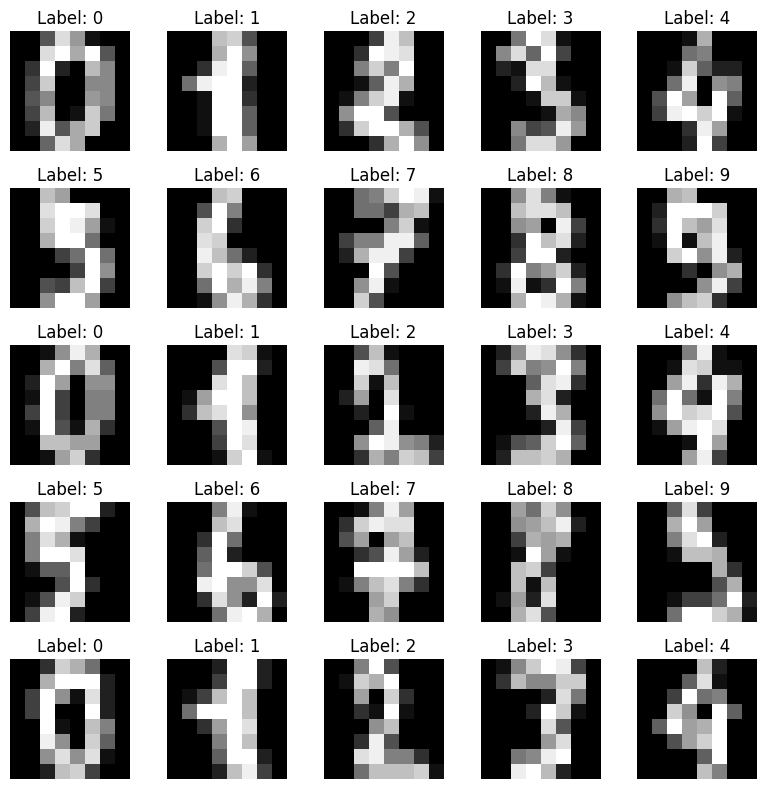

Dataset shape: (1797, 64)
Number of classes: 10


In [4]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

digits = load_digits()

fig, axes = plt.subplots(5, 5, figsize=(8,8))
for i, ax in enumerate(axes.flat):
  ax.imshow(digits.images[i], cmap='gray')
  ax.set_title(f"Label: {digits.target[i]}")
  ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Dataset shape: {digits.data.shape}")
print(f"Number of classes: {len(digits.target_names)}")


In [5]:
from sklearn.model_selection import train_test_split

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1437
Testing samples: 360


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Rgression Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Rgression Accuracy: 97.50%


In [7]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1000,
    random_state=42
)
mlp_model.fit(X_train, y_train)

mlp_predictions = mlp_model.predict(X_test)
mlp_accuracy = accuracy_score(y_test, mlp_predictions)

print(f"Neural Network Accuracy: {mlp_accuracy * 100:.2f}%")
print(f"Improvement over Logistic Regression: {(mlp_accuracy - lr_accuracy) * 100:.2f}%")

Neural Netowrk Accuracy: 97.22%
Improvement over Logistic Regression: -0.28%


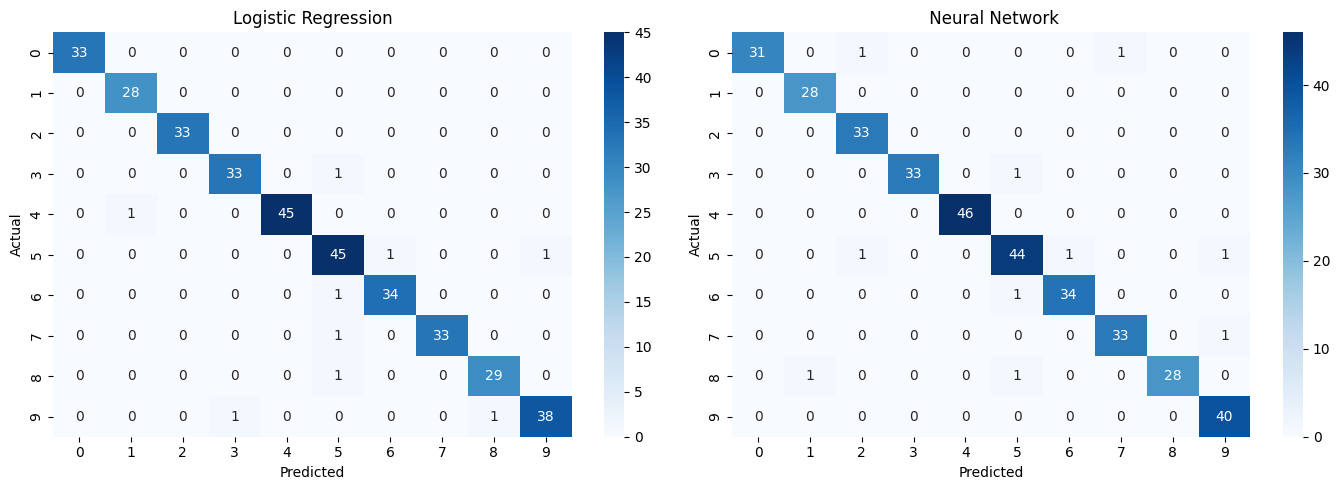

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as  sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
    [lr_predictions, mlp_predictions],
    ["Logistic Regression", " Neural Network"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=digits.target_names,
                yticklabels=digits.target_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

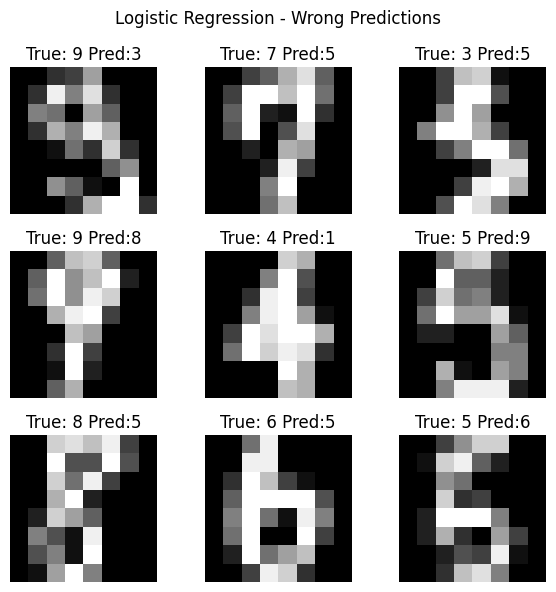

In [22]:
wrong_idx = [i for i in range(len(y_test)) if lr_predictions[i] != y_test[i]]

fig, axes = plt.subplots(3, 3, figsize=(6,6))
for i, ax in enumerate(axes.flat):
             if i >= len(wrong_idx): break
             idx = wrong_idx[i]
             ax.imshow(X_test[idx].reshape(8,8), cmap='gray')
             ax.set_title(f"True: {y_test[idx]} Pred:{lr_predictions[idx]}")
             ax.axis('off')
plt.suptitle("Logistic Regression - Wrong Predictions")
plt.tight_layout()
plt.show